The idea behind this analysis is to determine whether there are certain types of dishes Model 22 performs better in than the others (Model 3 V3 and Model 24 This will by first splitting the test dataset into carbohydrate buckets by increments of 10 ie 0-10, 11-20 and so on. The MSE will then be computed for three models in each bucket. This could reveal patterns of Model 22 being the best at smaller dishes, while Model 24 might be better in larger dishes.  

Imports

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Mounted at /content/drive


Paths

In [ ]:
MODEL22_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_22_Carbohydrate_estimator_plus_ingredient_estimator"
)

MODEL24_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor"
)

MODEL22_CSV = MODEL22_DIR / "model22_test_predictions_FIXED.csv"

MODEL24_CSV = (
    MODEL24_DIR
    / "verified_prediction_exports"
    / "model25_rdinet_predictions_test.csv"
)

OUT_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Bucketed_MSE_Comparison_Model3V3_Model22_Model24"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model 22 CSV:", MODEL22_CSV)
print("Model 24 CSV:", MODEL24_CSV)
print("Output directory:", OUT_DIR)

assert MODEL22_CSV.exists(), f"Missing file: {MODEL22_CSV}"
assert MODEL24_CSV.exists(), f"Missing file: {MODEL24_CSV}"

Model 22 CSV: /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/model22_test_predictions_FIXED.csv
Model 24 CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_test.csv
Output directory: /content/drive/MyDrive/Speciale/Models/Bucketed_MSE_Comparison_Model3V3_Model22_Model24


Loading and inspecting CSV files

In [ ]:
m22 = pd.read_csv(MODEL22_CSV)
m24 = pd.read_csv(MODEL24_CSV)

print("Model 22 shape:", m22.shape)
print("Model 24 shape:", m24.shape)

print("\nModel 22 columns:")
print(m22.columns.tolist())

print("\nModel 24 columns:")
print(m24.columns.tolist())

display(m22.head())
display(m24.head())

Model 22 shape: (507, 215)
Model 24 shape: (507, 15)

Model 22 columns:
['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_carb_pred', 'pred_ingr_almonds', 'pred_ingr_apple', 'pred_ingr_artichokes', 'pred_ingr_arugula', 'pred_ingr_asparagus', 'pred_ingr_avocado', 'pred_ingr_baby_carrots', 'pred_ingr_bacon', 'pred_ingr_bagels', 'pred_ingr_banana_with_peel', 'pred_ingr_basil', 'pred_ingr_beef', 'pred_ingr_beets', 'pred_ingr_bell_peppers', 'pred_ingr_berries', 'pred_ingr_black_beans', 'pred_ingr_blackberries', 'pred_ingr_blue_cheese', 'pred_ingr_blueberries', 'pred_ingr_bok_choy', 'pred_ingr_bread', 'pred_ingr_broccoli', 'pred_ingr_brown_rice', 'pred_ingr_brown_sugar', 'pred_ingr_brownies', 'pred_ingr_brussels_sprouts', 'pred_ingr_bulgur', 'pred_ingr_butter', 'pred_ingr_buttermilk', 'pred_ingr_cabbage', 'pred_ingr_caesar_dressing', 'pred_ingr_caesar_salad', 'pred_ingr_cantaloupe', 'pred_ingr_carrot', 'pred_ingr_cauliflower', 'pred_ingr_celery', 'pred_ingr_celery_root', 'pred_ingr_cere

,dish_id,total_carb,split,source_cafe,rgb_carb_pred,pred_ingr_almonds,pred_ingr_apple,pred_ingr_artichokes,pred_ingr_arugula,pred_ingr_asparagus,...,final_pred,abs_error,abs_error_rgb_only,old_final_pred_wrong,old_abs_error_wrong,abs_error_model22,squared_error_rgb_only,squared_error_model22,abs_error_improvement_model22_vs_rgb,squared_error_improvement_model22_vs_rgb
0,dish_1556575327,10.618,test,cafe1,12.507236,0.009016,0.000126,0.000004,2.917965e-07,0.000008,...,12.617384,1.999384,1.889236,12.507236,1.889236,1.999384,3.569213,3.997536,-0.110148,-0.428324
1,dish_1557861216,0.000,test,cafe1,1.025138,0.000008,0.000068,0.000049,2.531807e-07,0.000004,...,2.983665,2.983665,1.025138,1.025138,1.025138,2.983665,1.050909,8.902258,-1.958527,-7.851349
2,dish_1557862345,0.000,test,cafe1,1.074629,0.000251,0.000006,0.000220,7.137177e-07,0.000052,...,2.987030,2.987030,1.074629,1.074629,1.074629,2.987030,1.154827,8.922346,-1.912401,-7.767519
3,dish_1557862696,3.850,test,cafe1,3.543902,0.000012,0.000091,0.000028,4.340058e-08,0.000008,...,3.917544,0.067544,0.306098,3.543902,0.306098,0.067544,0.093696,0.004562,0.238553,0.089133
4,dish_1557862738,0.000,test,cafe1,4.563577,0.000086,0.000062,0.000468,2.328329e-04,0.000453,...,4.341109,4.341109,4.563577,4.563577,4.563577,4.341109,20.826232,18.845227,0.222468,1.981005


,dish_id,total_carb,split,source_cafe,rgb_path,depth_path,rgb_exists,depth_exists,rgb_size,depth_size,rdinet_carb_pred,rdinet_abs_error,rdinet_signed_error,rdinet_stage,rdinet_checkpoint
0,dish_1556575327,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,548259,311957,11.217070,0.599070,0.599070,stage_1,/content/drive/MyDrive/Speciale/Models/Model_2...
1,dish_1557861216,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,353804,307774,1.343749,1.343749,1.343749,stage_1,/content/drive/MyDrive/Speciale/Models/Model_2...
2,dish_1557862345,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,407501,304623,1.691291,1.691291,1.691291,stage_1,/content/drive/MyDrive/Speciale/Models/Model_2...
3,dish_1557862696,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,391780,307950,2.287569,1.562431,-1.562431,stage_1,/content/drive/MyDrive/Speciale/Models/Model_2...
4,dish_1557862738,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,412017,298067,2.843851,2.843851,2.843851,stage_1,/content/drive/MyDrive/Speciale/Models/Model_2...


Standardizing dataset

In [ ]:
def find_col(df, possible_names, file_name):
    for col in possible_names:
        if col in df.columns:
            return col
    raise ValueError(
        f"Could not find any of these columns in {file_name}: {possible_names}\n"
        f"Available columns are:\n{df.columns.tolist()}"
    )


# Model 22 CSV
m22_dish_col = find_col(m22, ["dish_id"], "Model 22 CSV")
m22_true_col = find_col(m22, ["total_carb"], "Model 22 CSV")

m3_pred_col = find_col(
    m22,
    ["rgb_only_pred", "rgb_carb_pred", "model3_v3_pred", "model3_pred"],
    "Model 22 CSV"
)

m22_pred_col = find_col(
    m22,
    ["model22_pred", "final_pred", "carb_output", "prediction"],
    "Model 22 CSV"
)

# Model 24 CSV
m24_dish_col = find_col(m24, ["dish_id"], "Model 24 CSV")
m24_true_col = find_col(m24, ["total_carb"], "Model 24 CSV")

m24_pred_col = find_col(
    m24,
    ["rdinet_carb_pred", "prediction", "model24_pred", "carb_pred"],
    "Model 24 CSV"
)

print("Using columns:")
print("Model 3 V3 prediction:", m3_pred_col)
print("Model 22 prediction:", m22_pred_col)
print("Model 24 prediction:", m24_pred_col)


m22_clean = m22[[m22_dish_col, m22_true_col, m3_pred_col, m22_pred_col]].copy()
m22_clean.columns = ["dish_id", "total_carb_m22", "model3_v3_pred", "model22_pred"]

m24_clean = m24[[m24_dish_col, m24_true_col, m24_pred_col]].copy()
m24_clean.columns = ["dish_id", "total_carb_m24", "model24_pred"]

m22_clean["dish_id"] = m22_clean["dish_id"].astype(str).str.strip()
m24_clean["dish_id"] = m24_clean["dish_id"].astype(str).str.strip()

df = m22_clean.merge(m24_clean, on="dish_id", how="inner")

print("Rows in Model 22 file:", len(m22_clean))
print("Rows in Model 24 file:", len(m24_clean))
print("Rows after merge:", len(df))

# Check that the true carbohydrate values match between the two files
df["truth_diff"] = (df["total_carb_m22"] - df["total_carb_m24"]).abs()

print("Maximum true carb difference:", df["truth_diff"].max())

if df["truth_diff"].max() > 1e-5:
    raise ValueError(
        "The true carbohydrate values do not match between the files. "
        "This may indicate that the wrong Model 24 CSV was loaded."
    )

df["total_carb"] = df["total_carb_m22"]

# Convert relevant columns to numeric
for col in ["total_carb", "model3_v3_pred", "model22_pred", "model24_pred"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df = df.dropna(subset=["total_carb", "model3_v3_pred", "model22_pred", "model24_pred"]).copy()
after = len(df)

print(f"Dropped {before - after} rows due to missing values.")
print("Final dataframe shape:", df.shape)

display(df.head())

Using columns:
Model 3 V3 prediction: rgb_only_pred
Model 22 prediction: model22_pred
Model 24 prediction: rdinet_carb_pred
Rows in Model 22 file: 507
Rows in Model 24 file: 507
Rows after merge: 507
Maximum true carb difference: 3.000000006636583e-06
Dropped 0 rows due to missing values.
Final dataframe shape: (507, 8)


,dish_id,total_carb_m22,model3_v3_pred,model22_pred,total_carb_m24,model24_pred,truth_diff,total_carb
0,dish_1556575327,10.618,12.507236,12.617384,10.618,11.217070,0.0,10.618
1,dish_1557861216,0.000,1.025138,2.983665,0.000,1.343749,0.0,0.000
2,dish_1557862345,0.000,1.074629,2.987030,0.000,1.691291,0.0,0.000
3,dish_1557862696,3.850,3.543902,3.917544,3.850,2.287569,0.0,3.850
4,dish_1557862738,0.000,4.563577,4.341109,0.000,2.843851,0.0,0.000


Checking correct load in by metrics

In [ ]:
def compute_metrics(y_true, y_pred):
    error = y_pred - y_true
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(error))
    return mse, rmse, mae

overall_rows = []

models = {
    "Model 3 V3": "model3_v3_pred",
    "Model 22": "model22_pred",
    "Model 24": "model24_pred"
}

for model_name, pred_col in models.items():
    mse, rmse, mae = compute_metrics(df["total_carb"], df[pred_col])
    overall_rows.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })

overall_metrics = pd.DataFrame(overall_rows)

overall_metrics_rounded = overall_metrics.copy()
overall_metrics_rounded[["MSE", "RMSE", "MAE"]] = overall_metrics_rounded[["MSE", "RMSE", "MAE"]].round(2)

display(overall_metrics_rounded)

,Model,MSE,RMSE,MAE
0,Model 3 V3,57.26,7.57,4.77
1,Model 22,50.89,7.13,4.62
2,Model 24,53.89,7.34,4.72


Creating carbohydrate buckets

In [ ]:
bins = [0, 10, 20, 30, 40, 50, 60, np.inf]
labels = ["0-10g", "10-20g", "20-30g", "30-40g", "40-50g", "50-60g", "60g+"]

df["carb_bucket"] = pd.cut(
    df["total_carb"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

print("Bucket counts:")
display(df["carb_bucket"].value_counts().sort_index())

Bucket counts:


,count
carb_bucket,
0-10g,188
10-20g,117
20-30g,82
30-40g,50
40-50g,37
50-60g,14
60g+,19


Computing MSE, RMSE and MAE per bucket

In [ ]:
bucket_rows = []

for bucket, group in df.groupby("carb_bucket", observed=True):
    row = {
        "Carb bucket": str(bucket),
        "N": len(group),
        "Mean true carbs": group["total_carb"].mean()
    }

    for model_name, pred_col in models.items():
        mse, rmse, mae = compute_metrics(group["total_carb"], group[pred_col])
        row[f"{model_name} MSE"] = mse
        row[f"{model_name} RMSE"] = rmse
        row[f"{model_name} MAE"] = mae

    mse_values = {
        model_name: row[f"{model_name} MSE"]
        for model_name in models.keys()
    }

    row["Best model by MSE"] = min(mse_values, key=mse_values.get)

    bucket_rows.append(row)

bucket_metrics = pd.DataFrame(bucket_rows)

bucket_mse_table = bucket_metrics[
    [
        "Carb bucket",
        "N",
        "Mean true carbs",
        "Model 3 V3 MSE",
        "Model 22 MSE",
        "Model 24 MSE",
        "Best model by MSE"
    ]
].copy()

for col in bucket_mse_table.columns:
    if col not in ["Carb bucket", "Best model by MSE"]:
        bucket_mse_table[col] = bucket_mse_table[col].round(2)

display(bucket_mse_table)

,Carb bucket,N,Mean true carbs,Model 3 V3 MSE,Model 22 MSE,Model 24 MSE,Best model by MSE
0,0-10g,188,4.07,9.46,10.22,8.15,Model 24
1,10-20g,117,14.92,24.21,26.92,33.51,Model 3 V3
2,20-30g,82,24.53,31.54,33.39,46.41,Model 3 V3
3,30-40g,50,33.74,56.23,58.98,42.96,Model 24
4,40-50g,37,45.67,160.50,124.28,143.31,Model 22
5,50-60g,14,55.15,236.83,185.79,304.98,Model 22
6,60g+,19,68.88,514.26,412.89,333.89,Model 24


Computing improvement from Model 22 vs the two other models

In [ ]:
improvement_table = bucket_metrics[
    [
        "Carb bucket",
        "N",
        "Model 3 V3 MSE",
        "Model 22 MSE",
        "Model 24 MSE"
    ]
].copy()

improvement_table["MSE improvement vs Model 3 V3"] = (
    improvement_table["Model 3 V3 MSE"] - improvement_table["Model 22 MSE"]
)

improvement_table["MSE improvement vs Model 24"] = (
    improvement_table["Model 24 MSE"] - improvement_table["Model 22 MSE"]
)

improvement_table["% improvement vs Model 3 V3"] = (
    improvement_table["MSE improvement vs Model 3 V3"]
    / improvement_table["Model 3 V3 MSE"]
    * 100
)

improvement_table["% improvement vs Model 24"] = (
    improvement_table["MSE improvement vs Model 24"]
    / improvement_table["Model 24 MSE"]
    * 100
)

for col in improvement_table.columns:
    if col != "Carb bucket":
        improvement_table[col] = improvement_table[col].round(2)

display(improvement_table)

,Carb bucket,N,Model 3 V3 MSE,Model 22 MSE,Model 24 MSE,MSE improvement vs Model 3 V3,MSE improvement vs Model 24,% improvement vs Model 3 V3,% improvement vs Model 24
0,0-10g,188,9.46,10.22,8.15,-0.76,-2.07,-8.09,-25.35
1,10-20g,117,24.21,26.92,33.51,-2.72,6.58,-11.23,19.65
2,20-30g,82,31.54,33.39,46.41,-1.85,13.02,-5.86,28.06
3,30-40g,50,56.23,58.98,42.96,-2.75,-16.01,-4.89,-37.27
4,40-50g,37,160.50,124.28,143.31,36.22,19.03,22.57,13.28
5,50-60g,14,236.83,185.79,304.98,51.04,119.19,21.55,39.08
6,60g+,19,514.26,412.89,333.89,101.37,-79.00,19.71,-23.66


Counting which model is best per dish within each bucket

In [ ]:
for model_name, pred_col in models.items():
    df[f"{model_name} squared_error"] = (df[pred_col] - df["total_carb"]) ** 2
    df[f"{model_name} abs_error"] = (df[pred_col] - df["total_carb"]).abs()

squared_error_cols = [f"{model_name} squared_error" for model_name in models.keys()]

df["Best model per dish"] = (
    df[squared_error_cols]
    .idxmin(axis=1)
    .str.replace(" squared_error", "", regex=False)
)

winner_counts = (
    df.groupby(["carb_bucket", "Best model per dish"], observed=True)
    .size()
    .reset_index(name="Dish count")
)

winner_pivot = (
    winner_counts
    .pivot(index="carb_bucket", columns="Best model per dish", values="Dish count")
    .fillna(0)
    .astype(int)
)

winner_pivot["N"] = winner_pivot.sum(axis=1)

for model_name in models.keys():
    if model_name in winner_pivot.columns:
        winner_pivot[f"{model_name} win %"] = (
            winner_pivot[model_name] / winner_pivot["N"] * 100
        ).round(1)

display(winner_pivot.reset_index())

Best model per dish,carb_bucket,Model 22,Model 24,Model 3 V3,N,Model 3 V3 win %,Model 22 win %,Model 24 win %
0,0-10g,36,84,68,188,36.2,19.1,44.7
1,10-20g,36,31,50,117,42.7,30.8,26.5
2,20-30g,30,25,27,82,32.9,36.6,30.5
3,30-40g,17,22,11,50,22.0,34.0,44.0
4,40-50g,17,14,6,37,16.2,45.9,37.8
5,50-60g,11,3,0,14,0.0,78.6,21.4
6,60g+,7,12,0,19,0.0,36.8,63.2


Plotting MSE by bucket

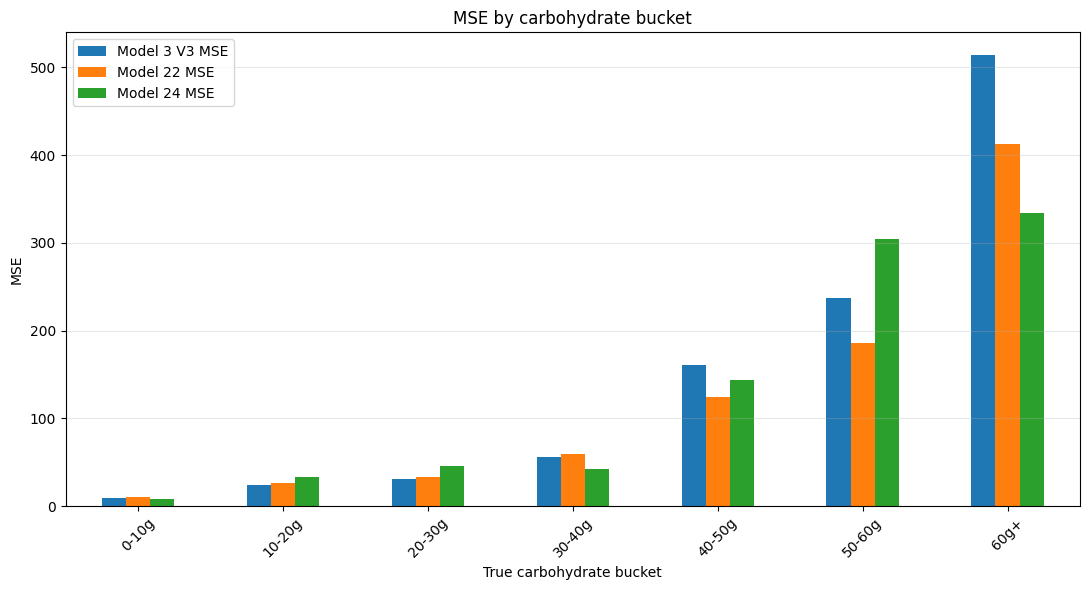

Saved plot to:
/content/drive/MyDrive/Speciale/Models/Bucketed_MSE_Comparison_Model3V3_Model22_Model24/bucket_mse_model3v3_model22_model24.png


In [ ]:
plot_df = bucket_metrics[
    ["Carb bucket", "Model 3 V3 MSE", "Model 22 MSE", "Model 24 MSE"]
].copy()

ax = plot_df.set_index("Carb bucket").plot(
    kind="bar",
    figsize=(11, 6),
    rot=45
)

ax.set_title("MSE by carbohydrate bucket")
ax.set_xlabel("True carbohydrate bucket")
ax.set_ylabel("MSE")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plot_path = OUT_DIR / "bucket_mse_model3v3_model22_model24.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to:")
print(plot_path)

Generating latex table for use in thesis

In [ ]:
latex_df = bucket_mse_table.copy()

latex_code = latex_df.to_latex(
    index=False,
    escape=True,
    caption="MSE by carbohydrate bucket for Model 3 V3, Model 22 and Model 24.",
    label="tab:bucket_mse_model_comparison",
    column_format="lrrrrl"
)

print(latex_code)

\begin{table}
\caption{MSE by carbohydrate bucket for Model 3 V3, Model 22 and Model 24.}
\label{tab:bucket_mse_model_comparison}
\begin{tabular}{lrrrrl}
\toprule
Carb bucket & N & Mean true carbs & Model 3 V3 MSE & Model 22 MSE & Model 24 MSE & Best model by MSE \\
\midrule
0-10g & 188 & 4.070000 & 9.460000 & 10.220000 & 8.150000 & Model 24 \\
10-20g & 117 & 14.920000 & 24.210000 & 26.920000 & 33.510000 & Model 3 V3 \\
20-30g & 82 & 24.530000 & 31.540000 & 33.390000 & 46.410000 & Model 3 V3 \\
30-40g & 50 & 33.740000 & 56.230000 & 58.980000 & 42.960000 & Model 24 \\
40-50g & 37 & 45.670000 & 160.500000 & 124.280000 & 143.310000 & Model 22 \\
50-60g & 14 & 55.150000 & 236.830000 & 185.790000 & 304.980000 & Model 22 \\
60g+ & 19 & 68.880000 & 514.260000 & 412.890000 & 333.890000 & Model 24 \\
\bottomrule
\end{tabular}
\end{table}



Bootstrap confidence intervals for bucket MSE and paired MSE difference

In [ ]:
N_BOOT = 5000
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

models = {
    "Model 3 V3": "model3_v3_pred",
    "Model 22": "model22_pred",
    "Model 24": "model24_pred"
}

def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

bootstrap_rows = []

for bucket, group in df.groupby("carb_bucket", observed=True):
    group = group.reset_index(drop=True)
    n = len(group)

    y_true = group["total_carb"].to_numpy()

    actual_mse = {
        model_name: mse(y_true, group[pred_col].to_numpy())
        for model_name, pred_col in models.items()
    }

    boot_mse = {model_name: [] for model_name in models.keys()}
    boot_diff_22_vs_3 = []
    boot_diff_22_vs_24 = []

    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        y_sample = y_true[idx]

        sampled_mse = {}
        for model_name, pred_col in models.items():
            pred_sample = group[pred_col].to_numpy()[idx]
            sampled_mse[model_name] = mse(y_sample, pred_sample)
            boot_mse[model_name].append(sampled_mse[model_name])

        boot_diff_22_vs_3.append(sampled_mse["Model 3 V3"] - sampled_mse["Model 22"])
        boot_diff_22_vs_24.append(sampled_mse["Model 24"] - sampled_mse["Model 22"])

    row = {
        "Carb bucket": str(bucket),
        "N": n,
    }

    for model_name in models.keys():
        values = np.array(boot_mse[model_name])
        row[f"{model_name} MSE"] = actual_mse[model_name]
        row[f"{model_name} MSE CI low"] = np.percentile(values, 2.5)
        row[f"{model_name} MSE CI high"] = np.percentile(values, 97.5)

    diff_3 = np.array(boot_diff_22_vs_3)
    diff_24 = np.array(boot_diff_22_vs_24)

    row["MSE improvement Model 22 vs Model 3 V3"] = actual_mse["Model 3 V3"] - actual_mse["Model 22"]
    row["Improvement vs Model 3 V3 CI low"] = np.percentile(diff_3, 2.5)
    row["Improvement vs Model 3 V3 CI high"] = np.percentile(diff_3, 97.5)

    row["MSE improvement Model 22 vs Model 24"] = actual_mse["Model 24"] - actual_mse["Model 22"]
    row["Improvement vs Model 24 CI low"] = np.percentile(diff_24, 2.5)
    row["Improvement vs Model 24 CI high"] = np.percentile(diff_24, 97.5)

    bootstrap_rows.append(row)

bootstrap_results = pd.DataFrame(bootstrap_rows)

bootstrap_display = bootstrap_results.copy()
numeric_cols = bootstrap_display.select_dtypes(include="number").columns
bootstrap_display[numeric_cols] = bootstrap_display[numeric_cols].round(2)

display(bootstrap_display)

,Carb bucket,N,Model 3 V3 MSE,Model 3 V3 MSE CI low,Model 3 V3 MSE CI high,Model 22 MSE,Model 22 MSE CI low,Model 22 MSE CI high,Model 24 MSE,Model 24 MSE CI low,Model 24 MSE CI high,MSE improvement Model 22 vs Model 3 V3,Improvement vs Model 3 V3 CI low,Improvement vs Model 3 V3 CI high,MSE improvement Model 22 vs Model 24,Improvement vs Model 24 CI low,Improvement vs Model 24 CI high
0,0-10g,188,9.46,6.81,12.54,10.22,7.77,13.06,8.15,5.09,12.54,-0.76,-1.53,0.03,-2.07,-4.59,1.04
1,10-20g,117,24.21,16.38,33.50,26.92,17.59,38.24,33.51,25.32,42.83,-2.72,-5.61,-0.31,6.58,-5.05,16.95
2,20-30g,82,31.54,21.48,42.67,33.39,23.03,44.97,46.41,32.28,61.77,-1.85,-6.05,2.06,13.02,1.83,24.46
3,30-40g,50,56.23,38.78,75.83,58.98,40.18,78.93,42.96,25.46,65.66,-2.75,-11.48,5.03,-16.01,-37.56,7.30
4,40-50g,37,160.50,87.71,245.95,124.28,58.27,205.93,143.31,80.54,211.58,36.22,25.16,47.49,19.03,-24.27,61.63
5,50-60g,14,236.83,112.62,377.30,185.79,72.48,320.53,304.98,179.12,447.29,51.04,30.46,74.13,119.19,22.63,203.33
6,60g+,19,514.26,358.30,678.91,412.89,275.24,560.75,333.89,188.13,500.15,101.37,77.83,125.46,-79.00,-187.51,40.07
